# Chapter 1: From Pixels to Sequences
## Building a Vision Transformer from Scratch

*Build a Multimodal Model from Scratch*

---

> **Who this chapter is for**: You have read *Build a Large Language Model
> from Scratch* and understand Transformers and multi-head attention.
> This chapter applies those ideas to images.

**The goal**: Build a model that turns a raw image into a sequence of
vectors — exactly the format a Transformer can process.

We will solve four problems, one by one:

| Problem | Solution | Section |
|---------|----------|---------|
| Images have 150,000+ pixels — way too many tokens | Cut into patches | 1.1 |
| How to turn a patch into a vector? | Conv2d trick | 1.2 |
| Transformer doesn't know where each patch came from | Positional embedding | 1.3 |
| N patches → N vectors, but we need ONE | [CLS] token | 1.4 |

After solving all four, we assemble the pieces into a Vision Transformer
and train it to classify images with >95% accuracy.

> **This chapter in context:** Ch01 builds the ViT visual backbone — patch embedding, bidirectional multi-head attention, and the [CLS] pooling token — that every subsequent chapter reuses. The same ViT architecture serves as the image encoder in CLIP (Ch02), the VLM (Ch03–04), MAE (Ch05), and the video encoder (Ch09). If ViT is new to you, this is the chapter to understand before proceeding.

In [1]:
%matplotlib inline
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Color palette used in all figures
PAL = dict(
    bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9',
    orange='#E67E22', green='#27AE60', red='#E74C3C',
    purple='#8E44AD', grey='#95A5A6'
)
print(f'Device: {DEVICE}')

Device: cpu


---
## Problem 1 — Too Many Pixels

Let's start with the obvious approach: feed every pixel as a token.

Run the cell below to see why that doesn't work.

In [2]:
# How many tokens would one image produce?
H, W, C_channels = 224, 224, 3
n_pixels = H * W * C_channels

# GPT-2's context window for comparison
gpt2_context = 1024

print(f'One 224x224 RGB image = {n_pixels:,} tokens')
print(f'GPT-2 context window  = {gpt2_context:,} tokens')
print(f'Ratio: {n_pixels / gpt2_context:.0f}x too many')
print()
# Attention cost is O(N^2)
print(f'Attention cost with pixels: O({n_pixels:,}^2) = O({n_pixels**2:,.0f})')
print('That is completely infeasible.')

One 224x224 RGB image = 150,528 tokens
GPT-2 context window  = 1,024 tokens
Ratio: 147x too many

Attention cost with pixels: O(150,528^2) = O(22,658,678,784)
That is completely infeasible.


**The fix**: instead of individual pixels, cut the image into small rectangular
**patches** and treat each patch as one token.

```
224 x 224 image  +  16x16 patch size  =  14 x 14 = 196 patches
```

196 tokens instead of 150,528 — a **768x** reduction.
Each patch still contains 16×16×3 = 768 pixel values, so we lose no information.

In [3]:
patch_size = 16
n_patches_per_side = 224 // patch_size   # 14
n_patches = n_patches_per_side ** 2      # 196
pixels_per_patch = patch_size * patch_size * 3  # 768

print(f'Patches per image : {n_patches}')
print(f'Pixels per patch  : {pixels_per_patch}')
print(f'Total information : {n_patches * pixels_per_patch:,} values (same as before)')
print()
print(f'Attention cost now: O({n_patches}^2) = O({n_patches**2:,})  <-- feasible!')

Patches per image : 196
Pixels per patch  : 768
Total information : 150,528 values (same as before)

Attention cost now: O(196^2) = O(38,416)  <-- feasible!


Here is what patch splitting looks like:

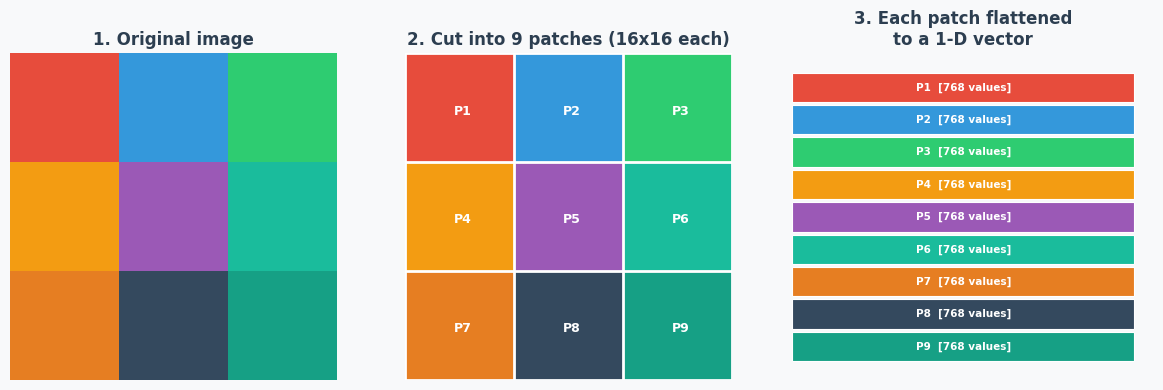

In [4]:
def draw_patch_splitting():
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.patch.set_facecolor(PAL['bg'])
    for ax in axes: ax.set_facecolor(PAL['bg'])

    # Panel 1: solid image
    img_size, P = 48, 16
    n = img_size // P
    colors = [['#e74c3c','#3498db','#2ecc71'],
               ['#f39c12','#9b59b6','#1abc9c'],
               ['#e67e22','#34495e','#16a085']]
    solid = np.zeros((img_size, img_size, 3))
    for r in range(n):
        for c in range(n):
            import matplotlib.colors as mc
            rgb = mc.to_rgb(colors[r][c])
            solid[r*P:(r+1)*P, c*P:(c+1)*P] = rgb
    axes[0].imshow(solid)
    axes[0].set_title('1. Original image', color=PAL['dark'], fontweight='bold')
    axes[0].axis('off')

    # Panel 2: image with patch grid
    axes[1].imshow(solid)
    for i in range(n + 1):
        axes[1].axhline(i * P - 0.5, color='white', lw=2)
        axes[1].axvline(i * P - 0.5, color='white', lw=2)
    for r in range(n):
        for c in range(n):
            axes[1].text(c*P + P/2, r*P + P/2, f'P{r*n+c+1}',
                         ha='center', va='center', color='white',
                         fontsize=9, fontweight='bold')
    axes[1].set_title(f'2. Cut into {n*n} patches ({P}x{P} each)',
                      color=PAL['dark'], fontweight='bold')
    axes[1].axis('off')

    # Panel 3: each patch as a flat bar
    flat = [colors[r][c] for r in range(n) for c in range(n)]
    bar_h = 0.85 / len(flat)
    for i, fc in enumerate(flat):
        y = 0.95 - (i + 1) * bar_h * 1.05
        rect = mpatches.Rectangle((0.05, y), 0.9, bar_h * 0.95,
                                   facecolor=fc, edgecolor='white', lw=0.8,
                                   transform=axes[2].transAxes)
        axes[2].add_patch(rect)
        axes[2].text(0.5, y + bar_h * 0.47, f'P{i+1}  [768 values]',
                     ha='center', va='center', color='white',
                     fontsize=7.5, fontweight='bold',
                     transform=axes[2].transAxes)
    axes[2].set_title('3. Each patch flattened\nto a 1-D vector',
                      color=PAL['dark'], fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

draw_patch_splitting()

---
## Problem 2 — Turning a Patch into a Vector

Each flattened patch is 768 numbers (16×16×3).  But the Transformer
expects all tokens to have the same dimension `D` (e.g. 512 or 768).

We need a **learnable linear projection**: multiply each flat patch by a
weight matrix `W` of shape `(768, D)`.

Let's build the naive version first — one loop per patch — so the math
is completely transparent.

In [5]:
class PatchEmbeddingNaive(nn.Module):
    """Pedagogical: explicit loop. Correct but slow."""

    def __init__(self, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        self.P = patch_size
        # One weight matrix shared across ALL patches
        flat_size = in_channels * patch_size * patch_size  # e.g. 3*8*8 = 192
        self.linear = nn.Linear(flat_size, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        P = self.P
        tokens = []
        for row in range(H // P):
            for col in range(W // P):
                patch = x[:, :, row*P:(row+1)*P, col*P:(col+1)*P]  # (B, C, P, P)
                flat  = patch.reshape(B, -1)                         # (B, C*P*P)
                tokens.append(self.linear(flat))                     # (B, D)
        return torch.stack(tokens, dim=1)                            # (B, N, D)


# Quick check
x    = torch.randn(2, 3, 32, 32)   # 2 images, 32x32 RGB
emb  = PatchEmbeddingNaive(patch_size=8, in_channels=3, embed_dim=64)
out  = emb(x)
# 32/8 = 4 patches per side, so 4*4 = 16 patches total
print(f'Input : {tuple(x.shape)}')
print(f'Output: {tuple(out.shape)}  <- (batch, n_patches, embed_dim)')
print('Works!')

Input : (2, 3, 32, 32)
Output: (2, 16, 64)  <- (batch, n_patches, embed_dim)
Works!


That loop works, but Python loops over patches are slow.  There is a
beautiful shortcut:

> A `Conv2d` with `kernel_size = stride = patch_size` slides a window
> across the image **without overlap**.  Each application multiplies one
> patch by the kernel weights — which is exactly the linear projection above.

Same math, fully vectorized, ~10x faster.

In [6]:
class PatchEmbedding(nn.Module):
    """Fast version: Conv2d with stride=kernel_size=patch_size."""

    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        # kernel_size=P, stride=P  =>  non-overlapping, one output per patch
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)          # (B, D, H/P, W/P)  — one vector per patch
        x = x.flatten(2)          # (B, D, N)          — collapse spatial dims
        x = x.transpose(1, 2)     # (B, N, D)          — sequence-first
        return x


# Prove they are numerically identical
torch.manual_seed(0)
x   = torch.randn(2, 3, 32, 32)
P, D = 8, 64
naive = PatchEmbeddingNaive(P, 3, D)
fast  = PatchEmbedding(img_size=32, patch_size=P, in_channels=3, embed_dim=D)

# Copy conv weights into linear layer so both use the same numbers
with torch.no_grad():
    naive.linear.weight.copy_(fast.proj.weight.view(D, -1))
    naive.linear.bias.copy_(fast.proj.bias)

diff = (naive(x) - fast(x)).abs().max().item()
print(f'Max difference between naive and fast: {diff:.2e}')
print('Mathematically identical.  We will use the fast version from now on.')

Max difference between naive and fast: 8.34e-07
Mathematically identical.  We will use the fast version from now on.


---
## Problem 3 — The Transformer Has No Sense of Direction

Here is something subtle.  A Transformer computes attention between
**all pairs** of tokens.  It doesn't matter which order you feed them in
— you will get the same attention weights (just in a different order).

For text, word order matters.  For images, spatial position matters even
more.  **Patch P1 (top-left) and patch P9 (center) carry different meaning**
— but without extra information, the Transformer can't tell them apart.

Let's see this problem in action:

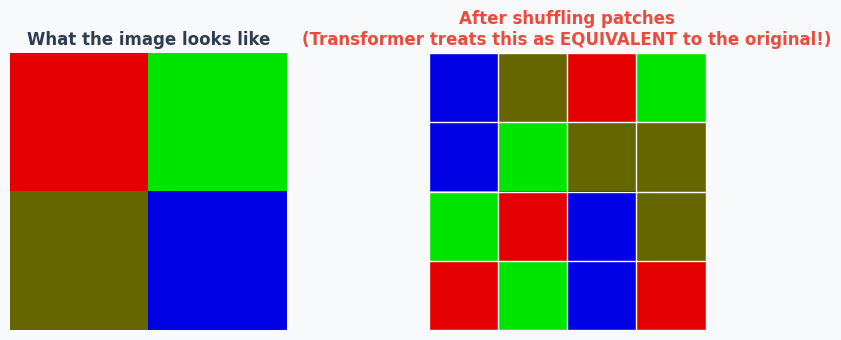

In [7]:
def show_position_problem():
    """Demonstrate that shuffling patches looks identical to the Transformer."""
    torch.manual_seed(7)
    img = torch.zeros(1, 3, 32, 32)
    img[0, 0, :16, :16] = 0.9   # top-left: red
    img[0, 2, 16:, 16:] = 0.9   # bottom-right: blue
    img[0, 1, :16, 16:] = 0.9   # top-right: green
    img[0, 0, 16:, :16] = 0.4   # bottom-left: dark
    img[0, 1, 16:, :16] = 0.4

    # Shuffle the patches
    P = 8
    unf = img.unfold(2, P, P).unfold(3, P, P)   # (1, 3, 4, 4, 8, 8)
    B, Ch, nh, nw, _, _ = unf.shape
    patches = unf.permute(0,2,3,1,4,5).reshape(-1, Ch, P, P)
    idx = torch.randperm(patches.shape[0])
    shuf = patches[idx].reshape(nh, nw, Ch, P, P)
    shuf = shuf.permute(2,0,3,1,4).reshape(Ch, nh*P, nw*P).unsqueeze(0)

    def to_np(t): return t.squeeze(0).permute(1,2,0).clamp(0,1).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    fig.patch.set_facecolor(PAL['bg'])

    axes[0].imshow(to_np(img))
    axes[0].set_title('What the image looks like', color=PAL['dark'], fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(to_np(shuf))
    for i in range(nh+1): axes[1].axhline(i*P-0.5, color='white', lw=1)
    for j in range(nw+1): axes[1].axvline(j*P-0.5, color='white', lw=1)
    axes[1].set_title(
        'After shuffling patches\n'
        '(Transformer treats this as EQUIVALENT to the original!)',
        color=PAL['red'], fontweight='bold'
    )
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

show_position_problem()

**The fix**: add a unique, learnable vector to each patch — like writing
the patch's grid address on it before handing it to the Transformer.

These are called **positional embeddings**.  They are just parameters:
a table of shape `(1, N+1, D)` that the model learns during training.
After training, patch P1's positional embedding will be different from
patch P9's, because the model learned that position matters.

In [8]:
class PositionalEmbedding(nn.Module):
    def __init__(self, n_patches: int, embed_dim: int):
        super().__init__()
        # +1 for the CLS token we'll add in the next section
        # Shape (1, N+1, D) broadcasts over the batch dimension
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)  # small random init

    def forward(self, x):
        return x + self.pos_embed   # (B, N+1, D) + (1, N+1, D) -> (B, N+1, D)


# Check: positional embedding doesn't change shape
pos = PositionalEmbedding(n_patches=16, embed_dim=64)
tokens = torch.randn(2, 17, 64)   # 2 images, 16 patches + 1 CLS slot
print(f'Before: {tuple(tokens.shape)}')
print(f'After : {tuple(pos(tokens).shape)}  (shape unchanged, values shifted)')

Before: (2, 17, 64)
After : (2, 17, 64)  (shape unchanged, values shifted)


---
## Problem 4 — Getting a Single Summary Vector

After the Transformer blocks, we have N output vectors — one per patch.
But for classification (or for feeding into a larger model), we need
**exactly one** vector that summarizes the whole image.

Two options:

| Option | How | Problem |
|--------|-----|--------|
| Average all N patch outputs | `tokens.mean(dim=1)` | Works, but "democratically" weights every patch equally |
| Add a special [CLS] token | Prepend one learnable token | This token attends to everything and learns to summarize |

ViT uses the **[CLS] token** (same idea as BERT).  Here is how to add it:

In [9]:
# The CLS token is just one learnable vector: shape (1, 1, D)
# We expand it to (B, 1, D) and prepend it to the patch tokens.

B, N, D = 2, 16, 64
patch_tokens = torch.randn(B, N, D)

cls_token = nn.Parameter(torch.zeros(1, 1, D))  # will be learned
cls_exp   = cls_token.expand(B, -1, -1)          # (2, 1, 64)

# CLS goes FIRST, then all patch tokens
tokens = torch.cat([cls_exp, patch_tokens], dim=1)  # (2, 17, 64)

print(f'Patch tokens : {tuple(patch_tokens.shape)}')
print(f'After CLS    : {tuple(tokens.shape)}')
print()
print('Layout of tokens[:, :, :] after this:')
print('  tokens[:, 0, :] = CLS token')
print('  tokens[:, 1, :] = Patch 1')
print('  tokens[:, 2, :] = Patch 2')
print('  ...')
print('After the Transformer, we read tokens[:, 0, :] as the image summary.')

Patch tokens : (2, 16, 64)
After CLS    : (2, 17, 64)

Layout of tokens[:, :, :] after this:
  tokens[:, 0, :] = CLS token
  tokens[:, 1, :] = Patch 1
  tokens[:, 2, :] = Patch 2
  ...
After the Transformer, we read tokens[:, 0, :] as the image summary.


---
## Bonus: One Difference from GPT Attention

If you've read the LLMs book, you know GPT attention well.  ViT uses
**the exact same code** — with one change:

**GPT** adds a causal mask (upper triangle = −∞) so each token only
attends to past tokens. This makes sense for generating text word by word.

**ViT** removes the mask entirely.  Every patch can attend to every
other patch.  There is no "future" in an image — patch P1 and patch P9
are just spatially different, not temporally ordered.

```python
# GPT: add this before softmax
mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
scores.masked_fill_(mask, float('-inf'))

# ViT: simply don't add the mask. That's the entire difference.
```

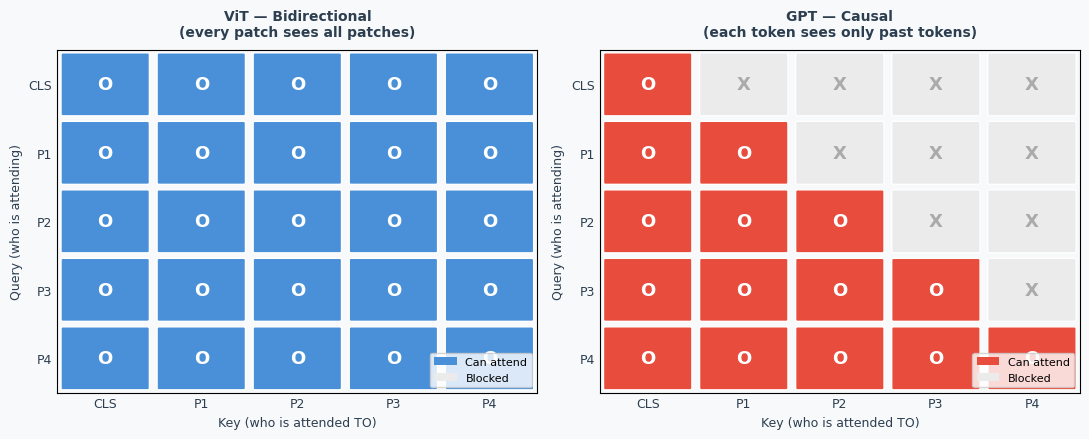

In [10]:
def draw_attention_comparison():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(PAL['bg'])
    T      = 5
    labels = ['CLS', 'P1', 'P2', 'P3', 'P4']

    configs = [
        (axes[0], 'ViT — Bidirectional\n(every patch sees all patches)', False, PAL['blue']),
        (axes[1], 'GPT — Causal\n(each token sees only past tokens)',    True,  PAL['red']),
    ]
    for ax, title, causal, color in configs:
        ax.set_facecolor(PAL['bg'])
        for i in range(T):
            for j in range(T):
                masked = causal and j > i
                fc  = '#EBEBEB' if masked else color
                txt = 'X'       if masked else 'O'
                tc  = '#AAAAAA' if masked else 'white'
                ax.add_patch(mpatches.FancyBboxPatch(
                    (j+0.06, T-i-1+0.06), 0.88, 0.88,
                    boxstyle='round,pad=0.02',
                    fc=fc, ec='white', lw=1.0
                ))
                ax.text(j+0.5, T-i-0.5, txt, ha='center', va='center',
                        color=tc, fontsize=13, fontweight='bold')
        ax.set_xlim(0, T); ax.set_ylim(0, T)
        ax.set_xticks([x+0.5 for x in range(T)])
        ax.set_yticks([y+0.5 for y in range(T)])
        ax.set_xticklabels(labels, color=PAL['dark'], fontsize=9)
        ax.set_yticklabels(labels[::-1], color=PAL['dark'], fontsize=9)
        ax.set_xlabel('Key (who is attended TO)',   color=PAL['dark'], fontsize=9)
        ax.set_ylabel('Query (who is attending)',   color=PAL['dark'], fontsize=9)
        ax.set_title(title, color=PAL['dark'], fontweight='bold', fontsize=10, pad=10)
        ax.tick_params(length=0)
        ax.legend(handles=[
            mpatches.Patch(fc=color,     label='Can attend'),
            mpatches.Patch(fc='#EBEBEB', label='Blocked'),
        ], loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

draw_attention_comparison()

Here is the attention module.  Compare it to the GPT version in the LLMs
book — the only missing piece is the causal mask.

In [11]:
class MultiHeadSelfAttention(nn.Module):
    """Bidirectional attention — no causal mask."""

    def __init__(self, embed_dim: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = embed_dim // n_heads
        self.scale    = self.head_dim ** -0.5  # 1/sqrt(d_head)
        self.qkv      = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        # Project to Q, K, V in one shot, then split
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)  # each: (B, H, N, d_head)
        # Scaled dot-product attention (no mask!)
        attn = F.softmax((q @ k.transpose(-2,-1)) * self.scale, dim=-1)
        attn = self.drop(attn)
        # Weighted sum, merge heads
        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.out_proj(out)

---
## Assembling the Full ViT

We have all the pieces.  Now stack them up.

Each Transformer block is identical to GPT's block — Pre-LayerNorm,
attention, FFN with residual connections:

In [12]:
class ViTBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, n_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        h = int(embed_dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, h), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h, embed_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # attention sub-layer
        x = x + self.ffn(self.norm2(x))    # FFN sub-layer
        return x


class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 embed_dim=768, depth=12, n_heads=12,
                 mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = PositionalEmbedding(n_patches, embed_dim)
        self.blocks    = nn.ModuleList(
            [ViTBlock(embed_dim, n_heads, mlp_ratio, dropout) for _ in range(depth)]
        )
        self.norm      = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x, return_all_tokens=False):
        B = x.shape[0]
        tokens = self.patch_embed(x)                        # (B, N, D)
        cls    = self.cls_token.expand(B, -1, -1)           # (B, 1, D)
        tokens = torch.cat([cls, tokens], dim=1)            # (B, N+1, D)
        tokens = self.pos_embed(tokens)                     # (B, N+1, D)
        for block in self.blocks:
            tokens = block(tokens)                          # (B, N+1, D)
        tokens = self.norm(tokens)
        if return_all_tokens:
            return tokens[:, 1:, :]   # (B, N, D) — used by VLM in Ch3
        return tokens[:, 0, :]        # (B, D)    — CLS summary

**Let's verify the pipeline works before training.**

Feed a dummy batch through and check every shape matches expectations:

In [13]:
torch.manual_seed(42)
vit = VisionTransformer(
    img_size=32, patch_size=8, in_channels=3,
    embed_dim=64, depth=2, n_heads=4
)

x = torch.randn(3, 3, 32, 32)   # 3 images

# Trace through each step
with torch.no_grad():
    patches  = vit.patch_embed(x)
    cls_exp  = vit.cls_token.expand(3, -1, -1)
    tokens   = torch.cat([cls_exp, patches], dim=1)
    tokens   = vit.pos_embed(tokens)
    for blk in vit.blocks:
        tokens = blk(tokens)
    cls_out  = tokens[:, 0, :]

print('Step-by-step shapes:')
print(f'  After PatchEmbedding   : {tuple(patches.shape)}   <- (batch, N, D)')
print(f'  After prepend CLS      : {tuple(torch.cat([cls_exp, patches], 1).shape)}')
print(f'  After PositionalEmbed  : {tuple(tokens.shape)}')
print(f'  CLS output             : {tuple(cls_out.shape)}   <- ready for classifier!')
print()
print(f'Total parameters: {sum(p.numel() for p in vit.parameters()):,}')

Step-by-step shapes:
  After PatchEmbedding   : (3, 16, 64)   <- (batch, N, D)
  After prepend CLS      : (3, 17, 64)
  After PositionalEmbed  : (3, 17, 64)
  CLS output             : (3, 64)   <- ready for classifier!

Total parameters: 113,600


---
## Training: Can It Actually Learn?

Theory is nice, but does it work?  Let's train on a simple 4-class dataset
and watch the model learn.

The dataset has four visually distinct patterns — a working model should
reach near-100% accuracy quickly:

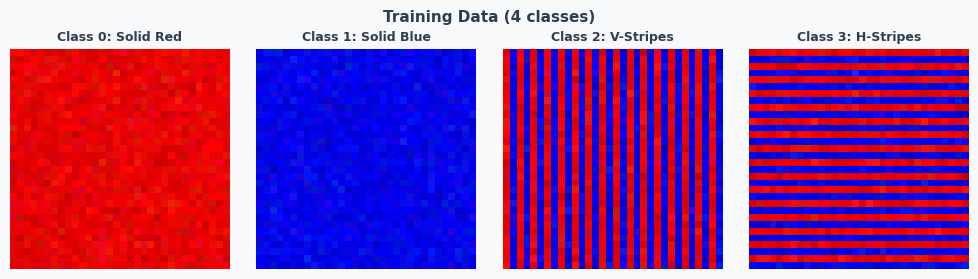

In [14]:
class SyntheticImageDataset(Dataset):
    """4-class image dataset: solid red, solid blue, vertical stripes, horizontal stripes."""

    CLASS_NAMES = ['Solid Red', 'Solid Blue', 'V-Stripes', 'H-Stripes']

    def __init__(self, n_per_class=200, img_size=32, seed=42):
        torch.manual_seed(seed)
        self.data = []
        for label in range(4):
            for _ in range(n_per_class):
                img   = torch.zeros(3, img_size, img_size)
                noise = torch.randn_like(img) * 0.05
                if label == 0:    img[0] = 0.9                    # red channel
                elif label == 1:  img[2] = 0.9                    # blue channel
                elif label == 2:  img[0, :, ::2] = img[2, :, 1::2] = 0.9  # v-stripes
                else:             img[0, ::2, :] = img[2, 1::2, :] = 0.9  # h-stripes
                self.data.append((img + noise, label))

    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]


def show_dataset_samples():
    ds = SyntheticImageDataset(n_per_class=1)
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
    fig.patch.set_facecolor(PAL['bg'])
    for i, (img, label) in enumerate(ds):
        axes[i].imshow(img.permute(1,2,0).clamp(0,1).numpy())
        axes[i].set_title(f'Class {label}: {ds.CLASS_NAMES[label]}',
                          color=PAL['dark'], fontsize=9, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle('Training Data (4 classes)', color=PAL['dark'],
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

show_dataset_samples()

In [15]:
class ViTClassifier(nn.Module):
    def __init__(self, n_classes, **vit_kwargs):
        super().__init__()
        self.vit  = VisionTransformer(**vit_kwargs)
        self.head = nn.Linear(vit_kwargs['embed_dim'], n_classes)

    def forward(self, x):
        return self.head(self.vit(x))   # CLS output -> class logits


def run_epoch(model, loader, optimizer=None):
    """One training or evaluation pass. Returns (avg_loss, accuracy)."""
    training = optimizer is not None
    model.train(training)
    total_loss = correct = total = 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = F.cross_entropy(logits, labels)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total


# ── Setup ─────────────────────────────────────────────────────────────────
torch.manual_seed(42)
ds = SyntheticImageDataset(n_per_class=200)
n_train = int(0.8 * len(ds))
train_ds, test_ds = torch.utils.data.random_split(ds, [n_train, len(ds)-n_train])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64)

model = ViTClassifier(
    n_classes=4,
    img_size=32, patch_size=8, in_channels=3,
    embed_dim=128, depth=4, n_heads=4
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(f'Trainable params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Train samples   : {len(train_ds)}')
print(f'Test  samples   : {len(test_ds)}')

# ── Train 30 epochs ──────────────────────────────────────────────────────
history = []
for epoch in range(1, 31):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
    te_loss, te_acc = run_epoch(model, test_loader)
    scheduler.step()
    history.append((tr_loss, tr_acc, te_acc))
    if epoch % 5 == 0:
        print(f'Epoch {epoch:2d}/30  '
              f'loss={tr_loss:.3f}  '
              f'train={tr_acc:.1%}  '
              f'test={te_acc:.1%}')

Trainable params: 820,868
Train samples   : 640
Test  samples   : 160


Epoch  5/30  loss=0.003  train=100.0%  test=100.0%


Epoch 10/30  loss=0.002  train=100.0%  test=100.0%


Epoch 15/30  loss=0.002  train=100.0%  test=100.0%


Epoch 20/30  loss=0.001  train=100.0%  test=100.0%


Epoch 25/30  loss=0.001  train=100.0%  test=100.0%


Epoch 30/30  loss=0.001  train=100.0%  test=100.0%


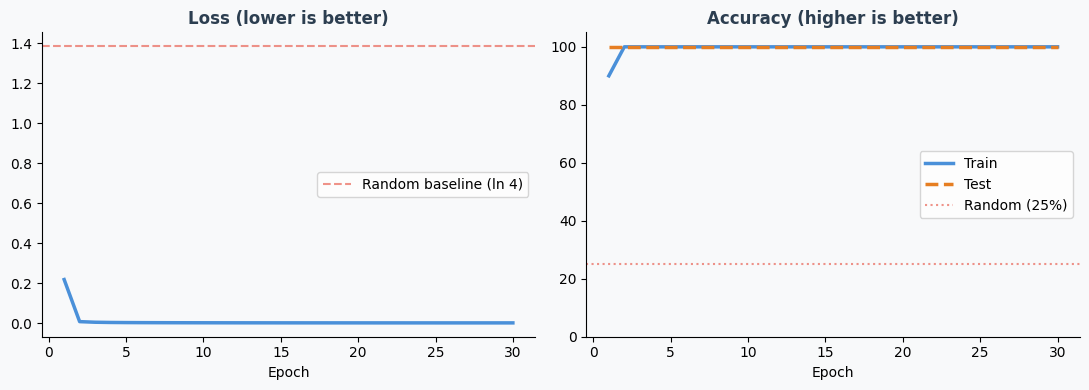

In [16]:
def plot_training(history):
    tr_losses = [h[0] for h in history]
    tr_accs   = [h[1]*100 for h in history]
    te_accs   = [h[2]*100 for h in history]
    epochs    = range(1, len(history)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    fig.patch.set_facecolor(PAL['bg'])

    ax1.set_facecolor(PAL['bg'])
    ax1.plot(epochs, tr_losses, color=PAL['blue'], lw=2.5)
    ax1.axhline(math.log(4), color=PAL['red'], ls='--', alpha=0.6,
                label=f'Random baseline (ln 4)')
    ax1.set_title('Loss (lower is better)', color=PAL['dark'], fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.legend(); ax1.spines[['top','right']].set_visible(False)

    ax2.set_facecolor(PAL['bg'])
    ax2.plot(epochs, tr_accs, color=PAL['blue'],   lw=2.5, label='Train')
    ax2.plot(epochs, te_accs, color=PAL['orange'], lw=2.5, ls='--', label='Test')
    ax2.axhline(25, color=PAL['red'], ls=':', alpha=0.6, label='Random (25%)')
    ax2.set_ylim(0, 105)
    ax2.set_title('Accuracy (higher is better)', color=PAL['dark'], fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.legend(); ax2.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_training(history)

Final accuracy check: let's look at individual predictions.
Green border = correct, red border = wrong.

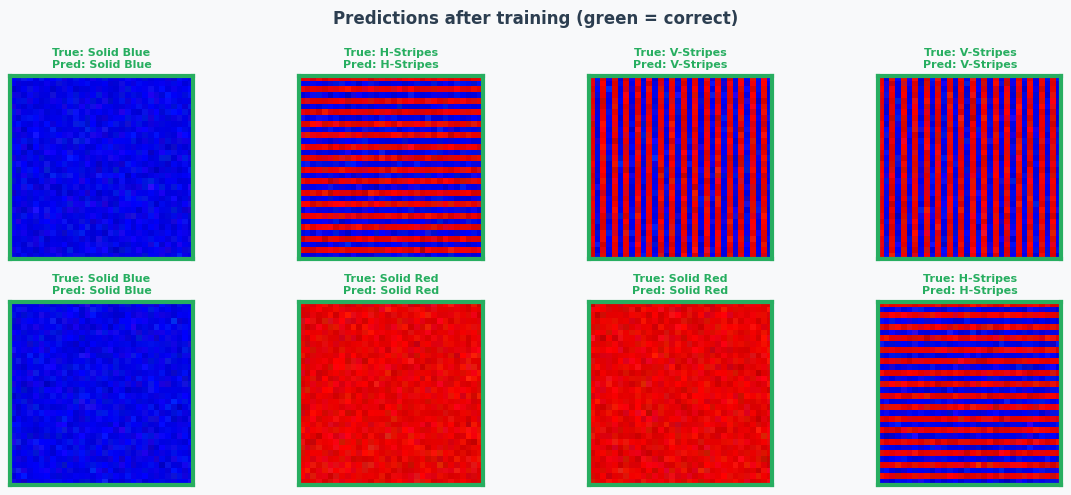

In [17]:
def show_predictions(model, dataset, n=8):
    model.eval()
    idx  = random.sample(range(len(dataset)), n)
    imgs = torch.stack([dataset[i][0] for i in idx]).to(DEVICE)
    true = [dataset[i][1] for i in idx]

    with torch.no_grad():
        pred = model(imgs).argmax(1).cpu().tolist()

    names = SyntheticImageDataset.CLASS_NAMES
    fig, axes = plt.subplots(2, n//2, figsize=(12, 5))
    fig.patch.set_facecolor(PAL['bg'])
    for k, ax in enumerate(axes.flatten()):
        img   = imgs[k].cpu().permute(1,2,0).clamp(0,1).numpy()
        ok    = pred[k] == true[k]
        color = PAL['green'] if ok else PAL['red']
        ax.imshow(img)
        ax.set_title(f'True: {names[true[k]]}\nPred: {names[pred[k]]}',
                     color=color, fontsize=8, fontweight='bold')
        for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(3)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.suptitle('Predictions after training (green = correct)',
                 color=PAL['dark'], fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(model, test_ds)

## Exercises

1. **Patch size experiment** — Change `patch_size` from `4` to `8`. How many patches does a 32×32 image now produce? Re-run training and compare final accuracy. What is the trade-off between patch size and sequence length?

2. **Global average pooling** — Remove the [CLS] token and replace `x[:, 0]` pooling with `x[:, 1:].mean(dim=1)` (average over all patch tokens). Does accuracy change? Which approach is more common in very large ViTs, and why?

3. **Sinusoidal positional embeddings** — Replace the learnable `nn.Parameter` positional embedding with 2-D sinusoidal encodings (one sin/cos pair per spatial frequency per axis). Plot both embedding matrices as heatmaps with `plt.imshow`. Do they encode a similar spatial structure?

## Scaling to Real Data

This notebook uses a minimal model to illustrate ViT mechanics. Here is how the hyperparameters map to production ViTs:

| Hyperparameter | This notebook | ViT-B/16 | ViT-L/16 |
|---|---|---|---|
| `patch_size` | 4 | 16 | 16 |
| `embed_dim` | 64 | 768 | 1 024 |
| `n_heads` | 4 | 12 | 16 |
| `n_layers` | 4 | 12 | 24 |
| Input resolution | 32×32 | 224×224 | 224×224 |
| Parameters | ~0.1 M | 86 M | 307 M |
| Pre-training data | 200 synthetic shapes | ImageNet-21k (14 M images) | ImageNet-21k |

**To use a real ViT-B/16 in place of this notebook's ViT:**
```python
from torchvision.models import vit_b_16, ViT_B_16_Weights
vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads = nn.Linear(768, num_classes)  # replace classification head
```
The `PatchEmbedding`, multi-head attention, and positional encoding you built here are exactly what is inside `vit_b_16`.

## Modern Perspective: Rotary Positional Embeddings (RoPE)

Every modern production LLM and VLM — LLaMA, Qwen, Gemini, GPT-4o, LLaVA-NeXT — has replaced learnable positional embeddings with **RoPE (Rotary Position Embeddings)** (Su et al., 2021). The ViT built in this chapter uses learnable embeddings; here is why production systems switched and what RoPE looks like from scratch.

**The problem with learnable embeddings:**
A learnable position embedding of size `(max_len, dim)` works well within training length but **cannot extrapolate** to longer sequences at inference time. If a ViT is trained on 224×224 images (196 patches) and you feed it a 448×448 image (784 patches), the embedding table has no entry for positions 197–784. Bilinear interpolation partially works, but it degrades.

**RoPE's solution — encode position as a rotation:**
Instead of adding a position vector to each token, RoPE *rotates* the query and key vectors by an angle proportional to position. The key insight: the dot product between a rotated query at position `m` and a rotated key at position `n` depends only on the *relative offset* `m - n`, not the absolute positions. This gives **free length generalisation**: the model sees relative positions during training and correctly handles longer sequences at inference.

**How it works geometrically:**
Split each head dimension into pairs `(x_{2i}, x_{2i+1})`. Rotate each pair by angle `m · θ_i` where `θ_i = 1/10000^{2i/d}`. The rotation matrix is:

```
[cos(mθᵢ)  -sin(mθᵢ)] [x₂ᵢ  ]
[sin(mθᵢ)   cos(mθᵢ)] [x₂ᵢ₊₁]
```

For multimodal models, 2D RoPE extends this to 2D spatial positions: separate frequencies for row and column — Qwen2-VL uses this to handle variable-resolution images without resizing.

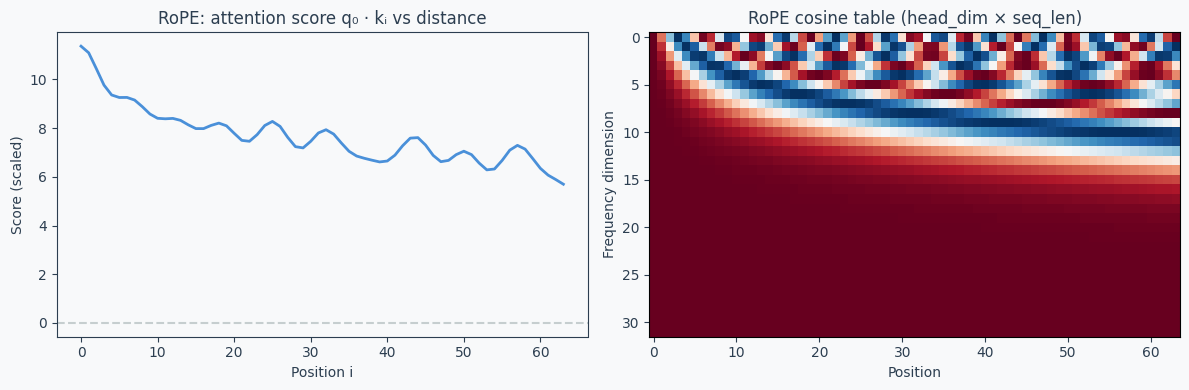

RoPE built: cos/sin tables shape = torch.Size([64, 32])
Key property: score decays with distance → natural relative-position bias
Compare learnable embeddings: each position has an independent vector,
no distance inductive bias, fails on unseen sequence lengths.


In [18]:
import torch, math
import matplotlib.pyplot as plt

def build_rope_freqs(seq_len, head_dim, base=10000):
    """Precompute RoPE cos/sin tables."""
    assert head_dim % 2 == 0
    theta = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    pos = torch.arange(seq_len).float()
    freqs = torch.outer(pos, theta)          # (seq_len, head_dim//2)
    return torch.cos(freqs), torch.sin(freqs)  # each (seq_len, head_dim//2)

def rotate_half(x):
    x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
    return torch.cat([-x2, x1], dim=-1)

def apply_rope(q, k, cos, sin):
    """Apply RoPE to query and key tensors."""
    # q, k: (B, n_heads, T, head_dim)
    # cos, sin: (T, head_dim//2) → broadcast to (1, 1, T, head_dim)
    cos = torch.cat([cos, cos], dim=-1).unsqueeze(0).unsqueeze(0)
    sin = torch.cat([sin, sin], dim=-1).unsqueeze(0).unsqueeze(0)
    q_rot = q * cos + rotate_half(q) * sin
    k_rot = k * cos + rotate_half(k) * sin
    return q_rot, k_rot

# ── Visualise: RoPE vs learnable positional embeddings ──
head_dim, seq_len = 64, 64
cos_table, sin_table = build_rope_freqs(seq_len, head_dim)

# RoPE: similarity between position 0 and all other positions
q0 = torch.randn(1, 1, 1, head_dim)
cos_0, sin_0 = cos_table[:1], sin_table[:1]
cos_all, sin_all = cos_table, sin_table

# Simulate attention score between position 0 and position i
scores_rope = []
for i in range(seq_len):
    qi, _ = apply_rope(q0, q0, cos_table[i:i+1], sin_table[i:i+1])
    k0, _ = apply_rope(q0, q0, cos_table[:1], sin_table[:1])
    s = (qi * k0).sum(-1).item() / math.sqrt(head_dim)
    scores_rope.append(s)

PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9', orange='#E67E22',
           green='#27AE60', red='#E74C3C')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor(PAL['bg'])

ax = axes[0]
ax.set_facecolor(PAL['bg'])
ax.plot(scores_rope, color=PAL['blue'], linewidth=2)
ax.axhline(0, color='#95A5A6', linestyle='--', alpha=0.5)
ax.set_title('RoPE: attention score q₀ · kᵢ vs distance', color=PAL['dark'])
ax.set_xlabel('Position i', color=PAL['dark'])
ax.set_ylabel('Score (scaled)', color=PAL['dark'])
ax.tick_params(colors=PAL['dark'])
for sp in ax.spines.values(): sp.set_color(PAL['dark'])

# RoPE frequency visualisation
ax2 = axes[1]
ax2.set_facecolor(PAL['bg'])
ax2.imshow(cos_table.T.numpy(), aspect='auto', cmap='RdBu_r')
ax2.set_title('RoPE cosine table (head_dim × seq_len)', color=PAL['dark'])
ax2.set_xlabel('Position', color=PAL['dark'])
ax2.set_ylabel('Frequency dimension', color=PAL['dark'])
ax2.tick_params(colors=PAL['dark'])

fig.tight_layout()
plt.savefig('/tmp/rope_vis.png', dpi=100, bbox_inches='tight',
            facecolor=PAL['bg'])
plt.show()
print(f"RoPE built: cos/sin tables shape = {cos_table.shape}")
print("Key property: score decays with distance → natural relative-position bias")
print("Compare learnable embeddings: each position has an independent vector,")
print("no distance inductive bias, fails on unseen sequence lengths.")

## Chapter Summary

**What we built** — A Vision Transformer that divides a 32×32 image into non-overlapping 4×4 patches, embeds each patch with a shared Conv2d projection, adds learnable positional encodings, prepends a learnable [CLS] token, and processes the sequence through 4 layers of bidirectional multi-head self-attention. The [CLS] output feeds a linear classifier trained on four synthetic colour-shape categories.

**Why it matters** — ViT proves that a pure Transformer (no convolutions in the backbone) can learn strong visual representations. The design choices made here — patches as tokens, positional embeddings, CLS pooling — have become the universal primitives of modern vision and multimodal models.

**Connections** — The ViT built here is the visual encoder that CLIP (Ch02) trains with contrastive supervision, that the VLM (Ch03) bridges to a language model, and that MAE (Ch05) pre-trains with masked reconstruction. The key difference from GPT's causal attention is what motivates the hybrid attention mask in Ch03.